# Visualization — UIT-VSFC Vietnamese Sentiment Dataset

**Mục tiêu:** Trực quan hóa các đặc điểm của dataset để rút ra insight phục vụ cho RQ.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

train = pd.read_csv('../data/processed/train_processed.csv')
dev   = pd.read_csv('../data/processed/dev_processed.csv')
test  = pd.read_csv('../data/processed/test_processed.csv')

print("Data loaded:")
print(f"  train: {len(train)} rows")


Data loaded:
  train: 11426 rows


In [16]:
import os
os.makedirs('../reports/figures', exist_ok=True)

## 1. Class Distribution:

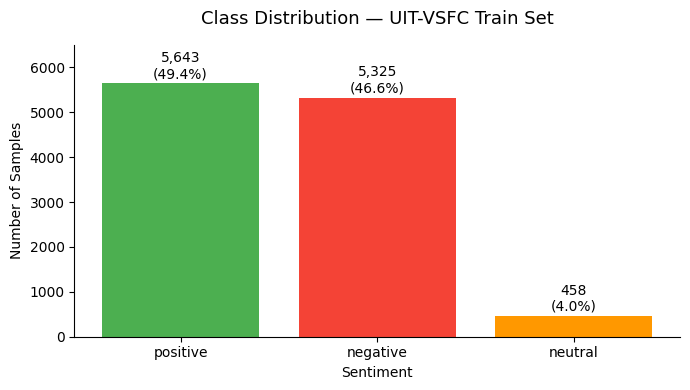

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'}
counts = train['Sentiment'].value_counts()

bars = ax.bar(counts.index, counts.values, color=[colors[s] for s in counts.index])

# Thêm số liệu lên đầu mỗi cột
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(train)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Class Distribution — UIT-VSFC Train Set', fontsize=13, pad=15)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, 6500)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Text Length Distribution by Sentiment

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24908\357459595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Sentiment', y='word_count',


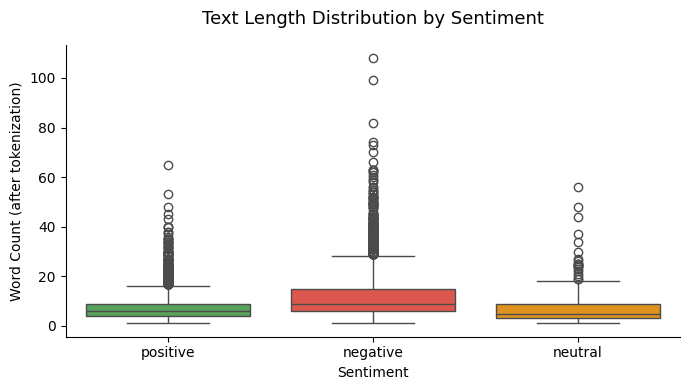

In [18]:
train['word_count'] = train['text_clean'].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=train, x='Sentiment', y='word_count',
            order=['positive', 'negative', 'neutral'],
            palette={'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'},
            ax=ax)

ax.set_title('Text Length Distribution by Sentiment', fontsize=13, pad=15)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Word Count (after tokenization)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Negative feedback dài hơn đáng kể so với positive (median 13 vs 8 từ), cho thấy sinh viên có xu hướng giải thích chi tiết hơn khi phàn nàn. Độ dài câu có thể là một feature phụ trợ hữu ích cho model.

## 3. Word Cloud by Sentiment
**Insight cần trả lời:** Từ nào đặc trưng cho từng nhãn sau khi đã tokenize?


In [19]:
import subprocess
subprocess.run(['pip', 'install', 'wordcloud'], capture_output=True)
print("Done")

Done


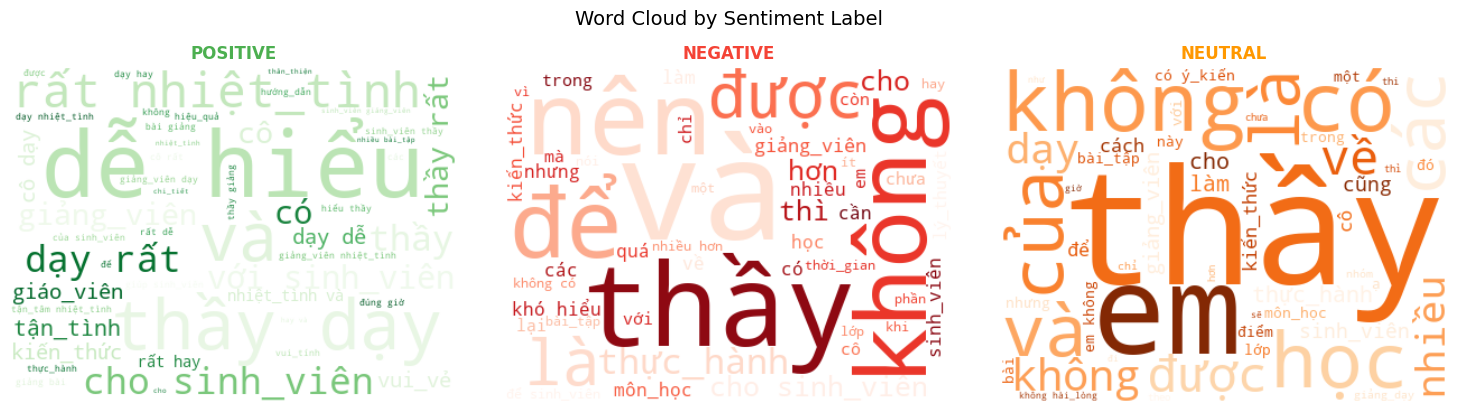

In [20]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('positive', '#4CAF50', axes[0]),
    ('negative', '#F44336', axes[1]),
    ('neutral',  '#FF9800', axes[2]),
]

for label, color, ax in configs:
    text = ' '.join(train[train['Sentiment'] == label]['text_clean'].dropna())
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='Greens' if label == 'positive' else ('Reds' if label == 'negative' else 'Oranges'),
        max_words=50
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label.upper(), fontsize=12, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud by Sentiment Label', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Từ `không` xuất hiện lớn ở cả negative lẫn neutral, từ phủ định là signal quan trọng nhưng không đủ để phân biệt hai nhãn này. `dễ_hiểu` và `khó_hiểu` là cặp từ đối lập đặc trưng nhất giữa positive và negative, cho thấy underthesea tokenize đúng giúp giữ nguyên ý nghĩa của từ ghép.
